https://archive.ics.uci.edu/dataset/967/phiusiil+phishing+url+dataset
PhiUSIIL Phishing URL (Website)

**Final Project**
Due May 7 by 11pm Points 100 Submitting a file upload File Types pdf Available until May 7 at 11:15pm
Up to this point, we have learned and discussed several machine learning algorithms. Now, it's time to put that knowledge into practice by applying these techniques to a problem of your own choosing. This could be any topic that sparks your interest!

To begin your project, consider areas you're passionate about, and look for publicly accessible datasets related to those interests.

You can explore the datasets/environments in Resources page under the Start Here module.

NOTE: The data or problem should be sufficiently complex, requiring a minimum of approximately 10,000 samples and at least 5 features.  In Data section, you should explicitly mention the size of data. 


The project requires a comprehensive machine learning pipeline, including: data exploration and analysis with appropriate visualizations; preprocessing (with explanations if not needed); selection of machine learning algorithms (at least two ML algorithms) with a rationale for each choice; and detailed observation and analysis of results, discussing whether the model performs as expected and identifying potential improvements.

* The bold face items above are key factors in determining your project grade.

**Submission**
**You are preparing a project report (pdf).  The recommended structure of the report contains:**

Cover page
- title
- name
  
Introduction

Data
- Introduce the data
- perform basic (visual) analysis
- Preprocessing
  
Methods
- details of your ML algorithms (at least two algorithms/models)
  
Results
- Explain detailed set up to solve the problem
- test your methods and show the results
- Discuss observation and analyze them
  
Conclusions
- conclude your work
- don't forget to mention what you have learned!
  
References
- It is important to cite others' work.
  
Acknowledgement
- if you use online resources and AI for your project, properly state them here how you use them. Check my slides for example acknowledgement.

Source Code
- Provide a GitHub link (make sure to be publicly accessible for grading)
  
**Use MLA style to cite and reference others work!**

# Using Machine Learning to Recongize Phishing URLs

#### 1    Introduction
This is the final individual report for ITSC 3156.  My project's goal is to utilize machine learning to train a model to help individuals to recognize fake job postings. The code can be located on github:  https://github.com/


#### 1.1  Problem Statement
Fake job posting is a significant concern for students graduating from universities and experienced job seekers, leading to wasted time, potential financial crimes, and misplaced career goals.  The increasing number of fraudulent listings on online job platforms highlights the need for effective detection methods to protect applicants.


#### 1.2  Motivation 
The motivation for our study is to assist job seekers in making better decisions about whether a job listing is credible or fake by developing a binary classification model.  According to an article in the *Wall Street Journal*, these positions are referred to as ghost jobs - "roles that companies advertise but have no intention of filling" and they account for one in five job postings online (cook).  "A similar survey from Resume Builder finds 40% of hiring managers admitted posting fake job listings in the last year, and 70% of them viewed the practice as perfectly acceptable." (zizka) The author offers suggestions such as verifying the posting is no more than 60 to 90 days, verifying postings by applying directly at the company website, and networking to locate opportunities before they are posted. 


#### 1.2  Challenges
The primary challenges in this study include creating constructing a robust model that does not rely on token-based analysis and large-language models, as well as identifying alternative models for predicting the validity of job postings.   Addiitionally, the original dataset contained a significant number of features with missing values, including within subset of fake postings.


#### 1.3  Concise Summary
In our study, the Real / Fake Job Posting Prediction dataset contains 18,000 postings of which 800 are classified as fake. The dataset includes various features such as job id, job title/entry, location, department, salary range, company profile, description, requirements, benefits, telecommuting, has company logo (presence of company logo), has questions (screening questions), employment type, required experience, required education, industry, function, fraudulent indicator.  The data contains both textual and meta information related to job postings. It was preprocessed and split into training (80 percent) and testing (20 precent).

#### 2    Data / environment

In [72]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

from typing import List, Dict, Tuple, Callable
import os
import gc
import traceback
import warnings
from pdb import set_trace

from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import mean_squared_error as mse

In [51]:
phishing = pd.read_csv("PhiUSIIL_Phishing_URL_Dataset.csv")
phishing.head(4)

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1


In [52]:
phishing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  object 
 1   URL                         235795 non-null  object 
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  object 
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  object 
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubDomain               235795 non-null  int64  
 13  HasObfuscation

In [53]:
phishing.isnull().sum()

FILENAME                      0
URL                           0
URLLength                     0
Domain                        0
DomainLength                  0
IsDomainIP                    0
TLD                           0
URLSimilarityIndex            0
CharContinuationRate          0
TLDLegitimateProb             0
URLCharProb                   0
TLDLength                     0
NoOfSubDomain                 0
HasObfuscation                0
NoOfObfuscatedChar            0
ObfuscationRatio              0
NoOfLettersInURL              0
LetterRatioInURL              0
NoOfDegitsInURL               0
DegitRatioInURL               0
NoOfEqualsInURL               0
NoOfQMarkInURL                0
NoOfAmpersandInURL            0
NoOfOtherSpecialCharsInURL    0
SpacialCharRatioInURL         0
IsHTTPS                       0
LineOfCode                    0
LargestLineLength             0
HasTitle                      0
Title                         0
DomainTitleMatchScore         0
URLTitle

In [54]:
phishing_clean = phishing.drop(["FILENAME", 'URL', 'URLLength', 'Domain', 'Title', 'TLD'], axis = 1)
phishing_clean.head(4)

,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,24,0,100.0,1.000000,0.522907,0.061933,3,1,0,0,...,0,0,1,34,20,28,119,0,124,1
1,16,0,100.0,0.666667,0.032650,0.050207,2,1,0,0,...,0,0,1,50,9,8,39,0,217,1
2,22,0,100.0,0.866667,0.028555,0.064129,2,2,0,0,...,0,0,1,10,2,7,42,2,5,1
3,19,0,100.0,1.000000,0.522907,0.057606,3,1,0,0,...,1,1,1,3,27,15,22,1,31,1


#### 2     Data

The PhiUSIIL Phishing URL dataset contains 235,795 URL  of which 100,945 are phishing URLs. The dataset includes fifty-four features related to an URL such as filename, URLLength, and domain which were extracted from the webpage source code by the author.  The data is tabular and contains real numbers, categorical values and integers. 

This dataset was downloaded from UC Irvine Machine Learning Repository (Shivam Bansal); however, documentation regarding its origin is unavailable.  The Kaggle page contains an acknowledgement to The University of the Aegean | Laboratory of Information & Communication Systems Security with a link; however, at the time of access, the link was down for service maintenance.

#### 2.1    Data visualization

Text(0, 0.5, 'Frequency')

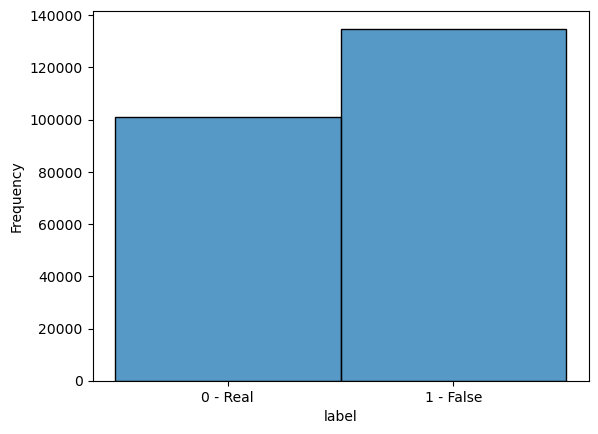

In [55]:
sns.histplot(phishing_clean["label"], bins=[-0.5,0.5,1.5], kde=False)
plt.xticks(ticks=[0,1], labels=['0 - Real', '1 - False'])
plt.ylabel('Frequency')

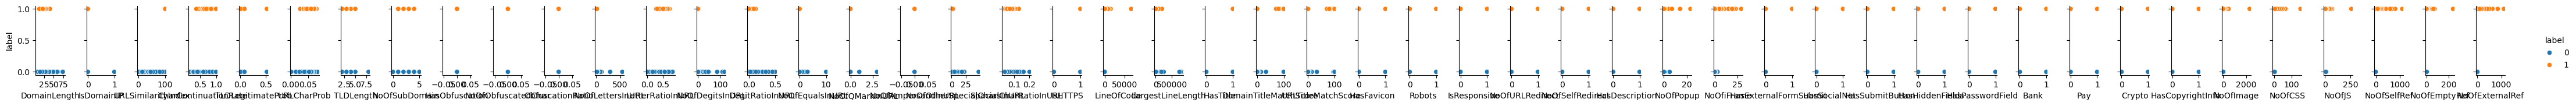

In [56]:
# https://seaborn.pydata.org/generated/seaborn.pairplot.html
#plt.figure(figsize=(12, 8))

rng = np.random.RandomState(0)
indices = rng.choice(np.arange(len(phishing_clean)), size=500, replace=False)
sns.pairplot(
    data=phishing_clean.iloc[indices],
    y_vars=['label'],  
    x_vars=list(phishing_clean.drop(columns=['label']).columns),  
    hue="label" ,
    height = 1.8,
    aspect = .5
)
plt.show()

c:\Users\WPB54760\anaconda3\envs\itcs-3156\lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(*plot_args, **plot_kwargs)
c:\Users\WPB54760\anaconda3\envs\itcs-3156\lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(*plot_args, **plot_kwargs)
c:\Users\WPB54760\anaconda3\envs\itcs-3156\lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(*plot_args, **plot_kwargs)
c:\Users\WPB54760\anaconda3\envs\itcs-3156\lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(*plot_args, **plot_kwargs)
c:\Users\WPB54760\anaconda3\envs\itcs-3156\lib\site-pack

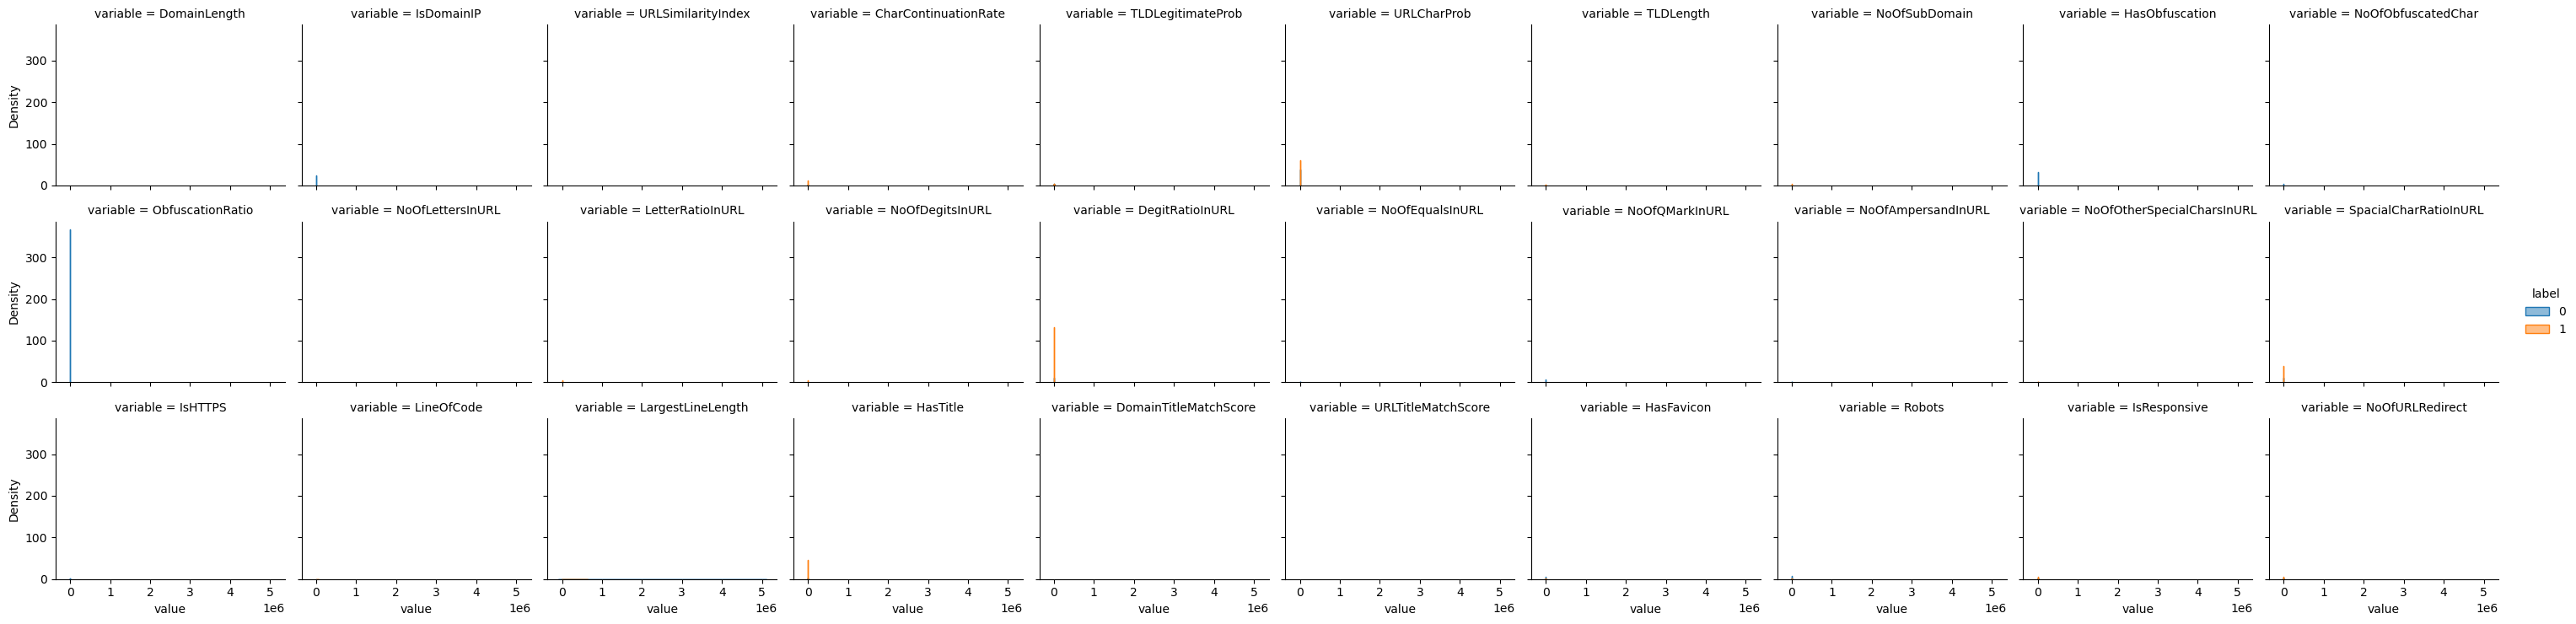

In [57]:
# Random sampling for better visualization
rng = np.random.RandomState(0)
indices = rng.choice(np.arange(len(phishing_clean)), size=5000, replace=False)  # Sample 5000 rows

# Select key features (for example, the first 30) to make it manageable
selected_features = list(phishing_clean.drop(columns=['label']).columns)[:30]  

# Convert to long format for FacetGrid
df_long = pd.melt(phishing_clean.iloc[indices], id_vars=['label'], value_vars=selected_features)

# Create FacetGrid to organize plots in rows of 10
g = sns.FacetGrid(df_long, col="variable", hue="label", col_wrap=10, height=2.5, aspect=1.2)
g.map(sns.kdeplot, "value", fill=True, alpha=0.5)  # Using KDE plots for better visualization
g.add_legend()

plt.show()

In [58]:
# https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.corr.html
phishing_clean.corr()

,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
DomainLength,1.000000,-0.041398,-0.420694,-0.577425,0.027209,-0.178104,0.152669,0.399157,0.041643,0.011304,...,-0.065895,-0.034773,-0.196860,-0.083458,-0.017596,-0.102216,-0.096712,-0.031673,-0.070099,-0.283152
IsDomainIP,-0.041398,1.000000,-0.121439,-0.101307,-0.053220,-0.111769,-0.011125,0.084619,0.001239,0.000354,...,-0.013863,-0.005919,-0.022796,-0.016502,-0.004149,-0.023126,-0.018981,-0.006793,-0.015269,-0.060202
URLSimilarityIndex,-0.420694,-0.121439,1.000000,0.572938,0.162042,0.571622,-0.053915,-0.058481,-0.100159,-0.032257,...,0.291542,0.087228,0.613620,0.235728,0.057683,0.315679,0.271590,0.091556,0.221960,0.860358
CharContinuationRate,-0.577425,-0.101307,0.572938,1.000000,0.237221,0.349810,0.051438,-0.482314,-0.036231,-0.004371,...,0.179145,0.059667,0.345566,0.135931,0.027943,0.183900,0.147881,0.049963,0.121745,0.467735
TLDLegitimateProb,0.027209,-0.053220,0.162042,0.237221,1.000000,0.274224,0.386794,-0.250048,-0.016577,0.001207,...,0.111494,0.038673,0.114394,0.053432,0.008296,0.058475,0.028216,0.015252,0.033182,0.097389
URLCharProb,-0.178104,-0.111769,0.571622,0.349810,0.274224,1.000000,0.069818,-0.081576,-0.056108,-0.029030,...,0.162323,0.062187,0.349530,0.128617,0.034470,0.176119,0.144543,0.050855,0.120841,0.469749
TLDLength,0.152669,-0.011125,-0.053915,0.051438,0.386794,0.069818,1.000000,-0.162431,0.000974,0.001902,...,0.023103,0.017689,-0.043484,-0.029074,-0.004249,-0.024109,-0.046451,-0.014442,-0.026486,-0.079159
NoOfSubDomain,0.399157,0.084619,-0.058481,-0.482314,-0.250048,-0.081576,-0.162431,1.000000,0.015902,-0.001477,...,-0.024983,-0.016590,-0.006321,-0.009474,-0.001003,-0.010226,0.003108,0.001702,-0.001538,-0.005955
HasObfuscation,0.041643,0.001239,-0.100159,-0.036231,-0.016577,-0.056108,0.000974,0.015902,1.000000,0.291858,...,-0.009674,-0.002711,-0.014249,-0.012997,-0.002841,-0.015700,-0.016541,-0.004463,-0.013342,-0.052473
NoOfObfuscatedChar,0.011304,0.000354,-0.032257,-0.004371,0.001207,-0.029030,0.001902,-0.001477,0.291858,1.000000,...,0.001481,-0.001472,0.002169,-0.003830,-0.000577,-0.003356,-0.004828,-0.001601,-0.003515,-0.015315


#### 2.2    Data Analysis

In [59]:
phishing.describe()

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
count,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,...,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000
mean,34.573095,21.470396,0.002706,78.430778,0.845508,0.260423,0.055747,2.764456,1.164758,0.002057,...,0.237007,0.023474,0.486775,26.075689,6.333111,10.522305,65.071113,2.377629,49.262516,0.571895
std,41.314153,9.150793,0.051946,28.976055,0.216632,0.251628,0.010587,0.599739,0.600969,0.045306,...,0.425247,0.151403,0.499826,79.411815,74.866296,22.312192,176.687539,17.641097,161.027430,0.494805
min,13.000000,4.000000,0.000000,0.155574,0.000000,0.000000,0.001083,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,0.000000,57.024793,0.680000,0.005977,0.050747,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,27.000000,20.000000,0.000000,100.000000,1.000000,0.079963,0.057970,3.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,8.000000,2.000000,6.000000,12.000000,0.000000,10.000000,1.000000
75%,34.000000,24.000000,0.000000,100.000000,1.000000,0.522907,0.062875,3.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,29.000000,8.000000,15.000000,88.000000,1.000000,57.000000,1.000000
max,6097.000000,110.000000,1.000000,100.000000,1.000000,0.522907,0.090824,13.000000,10.000000,1.000000,...,1.000000,1.000000,1.000000,8956.000000,35820.000000,6957.000000,27397.000000,4887.000000,27516.000000,1.000000


#### 2.3    Data Preprocessing

After downloading and importing the dataset, the first step was cleaning. The process began by removing highly descriptive features that would be useful for a tokenization project or a large language model (LLM) but useful for neural network projects. These features included *filename, URL, Domain, TLD, and Title*.  We also removed job_id since it provided no value to the algorithm.

During exploratory analysis, we discovered that the dataset contained many missing values, particularly within the subset of 800 fake listings. If we were to remove individual postings based solely on missing values, the subset would shrink from 800 listings to approximately 365, as required_education was missing in 451 cases.  Instead, we imputed the missing values for both required_experience and required_education as unspecified.  This leaves employment_type, which was removed from the final dataset.

With more than fifty features, we had to ensure that the dataset was properly scaled by stanrdizing, if possible perform dimension reduction, apply regularization to reduce risks of overfitting and feature engineering.






#### 3      Methods

In this section, an overview of the methods and algorithms used in the real / fake job posting project.  First, the data was processed by handling missing values 


#### 3.1    Neural Network without any Dimension Reduction

In [60]:
from sklearn.model_selection import train_test_split
def get_train_valid_test_data(
    X: np.ndarray, 
    y: np.ndarray, 
):
    """ Randomizes and then splits the data into train, validation, and test sets.

        Args:
            X: Data given as a 2D matrix

            y: Labels given as a vector 
    """
    assert isinstance(X, np.ndarray), f'`X` must be a NumPy array, got type {type(X)} instead.'
    assert isinstance(y, np.ndarray), f'`y` must be a NumPy array, got type {type(y)} instead.'
    X_trn, X_tst, y_trn, y_tst = train_test_split(X, y, train_size=.8, random_state=42)
    X_trn, X_vld, y_trn, y_vld = train_test_split(X_trn, y_trn, train_size=.8, random_state=42)

    return X_trn, y_trn, X_vld, y_vld, X_tst, y_tst

In [ ]:
# Standardization and Processing Data
from sklearn.preprocessing import StandardScaler

def get_preprocessed_data() -> Tuple[np.ndarray, ...]:
    """ Gets preprocessed data for training, validation, and testing

        Return:
            A tuple of NumPy arrays where indices 0-1 
            contain the training data/targets, indices 2-3
            contain the validation data/targets, and 4-5
            contain the testing data/targets.
    """

    # TODO 2.1 - 2.3
    # Drop the label column and store the features (pixel values) in X
    X = phishing_clean.drop('label', axis=1).values
    y = phishing_clean['label'].values

    X_trn, y_trn, X_vld, y_vld, X_tst, y_tst = get_train_valid_test_data(X, y)

    #standardize
    stand = StandardScaler()
    stand.fit(X_trn)  #compute the mean and std

    X_trn = stand.fit_transform(X_trn)  #standardizes 
  
    X_tst = stand.transform(X_tst)

    X_vld = stand.transform(X_vld)

    return X_trn, y_trn.reshape(-1, 1), X_vld, y_vld.reshape(-1, 1), X_tst, y_tst.reshape(-1, 1)

In [62]:
# LInear Activation Funtion

class Linear():
    """ The linear or identity actionvation function """
    @staticmethod
    def activation(z: np.ndarray) -> np.ndarray:
        """ Computes the output of the linear activation function """
        # TODO 3.1

        return z
        
    
    @staticmethod
    def derivative(z: np.ndarray) -> np.ndarray:
        """ Computes the derivative for the linear activation function """
        # TODO 3.2

        return np.ones(z.shape)

In [63]:
# Tanh activation function

class Tanh():
    """ The tanh actionvation function """
    @staticmethod
    def activation(z: np.ndarray) -> np.ndarray:
        """ Computes the output of the tanh activation function """
        # TODO 4.1

        return np.tanh(z)

    @staticmethod
    def derivative(z: np.ndarray) -> np.ndarray:
        """ Computes the derivative of the tanh activation function """
        # TODO 4.2

        return 1 - np.tanh(z)**2  

In [64]:
# Apply Initial Weights to Features

def init_weights(
    m_input_features: int, 
    hidden_neurons: int, 
    output_neurons: int, 
) -> Tuple[np.ndarray, ...]:
    """ Initilize the hidden and output layer parameters
        
        Args:
            m_input_features: The number of input features

            hidden_neurons: The number of hidden neurons or units to 
                use in the hidden layer.

            output_neurons: The number of output neurons to use in 
                the output layer.

        Returns:
            A tuple of NumPy arrays containing the weights and biases
            for the hidden and output layers.
    """
    # TODO 5
    # https://numpy.org/doc/stable/reference/random/generated/numpy.random.uniform.html

    W1 =  np.random.uniform(low=-0.5, high=0.5, size=(m_input_features, hidden_neurons))
    #b1 = np.ones((1, hidden_neurons)).reshape(1,-1)
    b1 = np.ones([1, hidden_neurons]).reshape(1,-1)
    W2 = np.random.uniform(low=-0.5, high=0.5, size=(hidden_neurons, output_neurons))
    #b2 = np.ones((1, output_neurons)).reshape(1,-1)
    b2 = np.ones([1, output_neurons]).reshape(1,-1)

    assert W1.shape == (m_input_features, hidden_neurons), "W1 shape mismatch!"
    assert b1.shape == (1, hidden_neurons), "b1 shape mismatch!"
    assert W2.shape == (hidden_neurons, output_neurons), "W2 shape mismatch!"
    assert b2.shape == (1, output_neurons), "b2 shape mismatch!"

    
    return W1, b1, W2, b2

In [65]:
# Forward Pass
def forward(
    X: np.ndarray, 
    W1: np.ndarray, 
    b1: np.ndarray,
    W2: np.ndarray, 
    b2: np.ndarray, 
) -> Tuple[np.ndarray, ...]:
    """ Forward pass for 2 layer neural network
    
        Args:
            X: Input features
            
            W1: Hidden layer weights 
            
            b1: Hidden layer baises

            W2: Output layer weights 
            
            b2: Output layer baises

        Returns:
            A tuple of NumPy arrays containing the linear combination and 
            acitvation outputs for each layer. These are needed to compute 
            the backward pass.
    """

    # TODO 6
    
    Z1 = X @ W1 + b1                                                                                 #.reshape(1,-1)   ADDED .reshape(1,-1)
    A1 = Tanh.activation(Z1)  #usage in TEST.linear
    Z2 = A1 @ W2 + b2                                                                                #.reshape(1,-1);  comeback and remove .reshape(1,-1) and reTEST
    A2 = Linear.activation(Z2)

    return Z1, A1, Z2, A2

In [66]:
# Backward
def output_layer_grads(
    X: np.ndarray,
    y: np.ndarray,
    W1: np.ndarray,
    Z1: np.ndarray,
    A1: np.ndarray,
    W2: np.ndarray,
    Z2: np.ndarray,
    A2: np.ndarray
) -> Tuple[np.ndarray, np.ndarray]:
    """ Compute gradients for the output layer parameters
        
        Note:
            You might not use all the passed arguments!
    
        Args:
            X: Input data given as a matrix
            
            y: Ground truth labels given as a column vector

            W1: Hidden layer weights
            
            Z1: Linear combination output for hidden layer

            A1: Activation output for hidden layer
            
            W2: Output layer weights

            Z2: Linear combination output for the output layer

            A2: Activation output or the output layer. Also 
                referred to as y_hat.
            
        Return:
            A tuple of NumPy arrays containing the average gradient 
            for the output layer weights and biases.
    """
    # TODO 7

    #W2_avg_grad = (A1.T @ (A2 - y)) / y.shape[0]
    #b2_avg_grad = (A2 - y).mean(axis = 0).reshape(1, 1)
    
    # code reused from note-neural-network provided by professor
    def delta_mse(y, y_hat):
        return y_hat - y
            
    y_hat = A2
    delta_mse_A2 = delta_mse(y, y_hat)
    delta_A2_Z2 = Linear.derivative(Z2)
    #delta_Z2_b2 = np.ones([len(y), 1])
    delta_Z2_b2 = np.ones([y.shape[0], 1])
    delta_Z2_W2 = A1

    delta_mse_Z2 = delta_mse_A2 * delta_A2_Z2
    #print(f"{delta_mse_Z2.shape} = {delta_mse_A2.shape} * {delta_A2_Z2.shape}")

    delta_mse_W2 = delta_Z2_W2.T  @ delta_mse_Z2 
    #print(f"{delta_mse_W2.shape} = {delta_Z2_W2.T.shape} @ {delta_mse_Z2.shape}")

    # Average Gradient
    #W2_avg_grad = delta_mse_W2 / len(y) 
    W2_avg_grad = delta_mse_W2 / y.shape[0] 
    

    # Gradient
    delta_mse_Z2 = delta_mse_A2 * delta_A2_Z2
    #print(f"{delta_mse_Z2.shape} = {delta_mse_A2.shape} * {delta_A2_Z2.shape}")
    
    delta_mse_b2 = delta_Z2_b2.T @  delta_mse_Z2
    #print(f"{delta_mse_b2.shape} = {delta_Z2_b2.T.shape} @ {delta_mse_Z2.shape}")
    
    # Average Gradient
    b2_avg_grad = delta_mse_b2 / len(y) 
    
    return W2_avg_grad, b2_avg_grad

In [67]:
# Hidden Layer

def hidden_layer_grads(
    X: np.ndarray,
    y: np.ndarray,
    W1: np.ndarray,
    Z1: np.ndarray,
    A1: np.ndarray,
    W2: np.ndarray,
    Z2: np.ndarray,
    A2: np.ndarray
) -> Tuple[np.ndarray, np.ndarray]:
    """ Compute gradients for the hidden layer parameters
        
        Note:
            You might not use all the passed arguments!
    
        Args:
            X: Input data given as a matrix
            
            y: Ground truth labels given as a column vector

            W1: Hidden layer weights
            
            Z1: Linear combination output for hidden layer

            A1: Activation output for hidden layer
            
            W2: Output layer weights

            Z2: Linear combination output for the output layer

            A2: Activation output or the output layer. Also 
                referred to as y_hat.
            
        Return:
            A tuple of NumPy arrays containing the average gradient 
            for the hidden layer weights and biases.
    """
    # TODO 8
    #W1_avg_grad = (X.T @ (A2 - y) @ W2.T @ (1- Tanh.activation(Z1))) / len(X)
    #b1_avg_grad = ((A2 - y) @ W2.T @ (1- Tanh.activation(Z1))).mean(axis =0)  does pass Test but used professor's code from example

    # code reused from note-neural-network provided by professor
    y_hat = A2

    #def delta_mse(y, y_hat):
    #   return y_hat - y   delta_mse(y, y_hat)

    delta_mse_A2 = y_hat - y
    delta_A2_Z2 = Linear.derivative(Z2)
    delta_Z2_A1 = W2
    delta_A1_Z1 = Tanh.derivative(Z1)
    delta_Z1_W1 = X

    delta_mse_A1 = (delta_mse_A2 * delta_A2_Z2) @ delta_Z2_A1.T
    #print(f"{delta_mse_A1.shape} =  {delta_mse_A2.shape} * {delta_A2_Z2.shape} @ {delta_Z2_A1.T.shape}")

    delta_mse_W1 = delta_Z1_W1.T @ ( delta_mse_A1 * delta_A1_Z1 )
    #print(f"{delta_mse_W1.shape} = {delta_Z1_W1.T.shape} @ ({delta_mse_A1.shape} * {delta_A1_Z1.shape})")

    W1_avg_grad = delta_mse_W1 / y.shape[0]

    delta_Z1_b1 = np.ones([y.shape[0], 1])

    delta_mse_b1 =  delta_Z1_b1.T @ (delta_mse_A1 * delta_A1_Z1)
    #print(f"{delta_mse_b1.shape} = {delta_Z1_b1.T.shape} @ ({delta_mse_A1.shape} * {delta_A1_Z1.shape})")

    b1_avg_grad = delta_mse_b1 / y.shape[0]
    
    return W1_avg_grad, b1_avg_grad

In [70]:
# Create batches

def get_batches(
    data_len: int, 
    batch_size: int = 32,
) -> List[np.ndarray]:
    """ Generates mini-batches based on the data indexes
        
        Args:
            data_len: Length of the data or number of data samples 
                in the data. This is used to generate the indices of
                the data.
            
            batch_size: Size of each mini-batch where the last mini-batch
                might be smaller than the rest if the batch_size does not 
                evenly divide the data length.

        Returns:
            A list of NumPy array's holding the indices of batches
    """
    indices = np.arange(data_len)
    np.random.shuffle(indices)
    batches = [indices[i:i+batch_size] for i in range(0, data_len, batch_size)]

    return batches

In [68]:
# Neural Network
class NeuralNetwork():
    def __init__(self,
        hidden_neurons: int,
        output_neurons: int,
        alpha: float, 
        batch_size: int,
        epochs: int = 1,
        seed: int = 0,
    ):
        """ A two layer neural network using SGD
            
            Attributes:
                hidden_neurons: Number of hidden units/neurons.
                
                output_neurons: Number of output neuorns
                
                alpha: learning rate or step size.
                
                batch_size: Size of mini-batches for mini-batch gradient
                    descent.
                
                epochs: Number of epochs to run for mini-batch
                    gradient descent.
                    
                seed: Seed to be used for NumPy's np.random.seed() function.
    
                W1: Hidden layer weights with shape (inputs, neurons)
                
                b1: Hidden layer baises with shape (1, neurons)
                
                W2: Output layer weights with shape (inputs, neurons)
                
                b2: Output layer baises with shape (1, neurons)
    
                trn_error: Stores the training error for each epoch.
    
                vld_error: Stores the validation error for each epoch.
        """
        self.hidden_neurons = hidden_neurons
        self.output_neurons = output_neurons
        self.batch_size = batch_size
        self.alpha = alpha
        self.epochs = epochs
        self.seed = seed
        
        self.W1, self.b1 = None, None
        self.W2, self.b2 = None, None
        self.trn_error = None
        self.vld_error = None

    def fit(
        self,
        X: np.ndarray, 
        y: np.ndarray,
        X_vld: np.ndarray = None, 
        y_vld:np.ndarray = None,
    ): 
        """ Trains a basic two layer neural network using SGD
        
            Args:
                X: Training data given as a 2D matrix

                y: Training labels given as a 2D column vector

                X_vld: Validation data given as a 2D matrix. Used 
                    to compute the validation RMSE for each epoch.

                y_vld: Validation labels given as a 2D matrix. Used 
                    to compute the validation RMSE for each epoch.
                
            Returns:
                The class's own object reference. 
        """
        np.random.seed(self.seed)
        self.trn_error = []
        self.vld_error = []
        
        # TODO 9.1 - 9.2
        self.W1, self.b1, self.W2, self.b2 = init_weights(X.shape[1], self.hidden_neurons,  self.output_neurons)
        
        for e in range(self.epochs):
            batches = []

            batches = get_batches(len(X),self.batch_size)

            for b in batches:

                Z1, A1, Z2, A2 = forward(X=X[b], W1=self.W1, b1=self.b1, W2=self.W2, b2=self.b2)

                #print("Output Layer")
                W2_avg_grad, b2_avg_grad = output_layer_grads(X[b], y[b], self.W1, Z1, A1, self.W2, Z2, A2)

                #print("hidden layer")
                W1_avg_grad, b1_avg_grad = hidden_layer_grads(X[b], y[b], self.W1, Z1, A1, self.W2, Z2, A2)


                self.W2 -= self.alpha * W2_avg_grad
                self.b2 -= self.alpha * b2_avg_grad
                
                self.W1 -= self.alpha * W1_avg_grad
                self.b1 -= self.alpha * b1_avg_grad  


            trn_preds = self.predict(X)
            trn_error = rmse(y, trn_preds)
            self.trn_error.append(trn_error)

            if X_vld is not None and y_vld is not None:
                vld_preds = self.predict(X_vld)
                vld_error = rmse(y_vld, vld_preds)
                self.vld_error.append(vld_error)
        
        return self
    
    def predict(self, X: np.ndarray):
        """ Make predictions using forward pass.

            Args:
                X: Testing data given as a 2D matrix

            Returns:
                A 2D column vector of predictions for each data sample in X
        """
        # TODO 9.3
        Z1, A1, Z2, A2 = forward(X=X, W1=self.W1, b1=self.b1, W2=self.W2, b2=self.b2)
        return  A2

Train MSE: 0.00011060664595859682
Train RMSE: 0.010516969428433118
Validation MSE: 0.00011637581270834293
Train RMSE: 0.010787762173330618
Test MSE: 0.00010521815551091002
Train RMSE: 0.010257590141495711


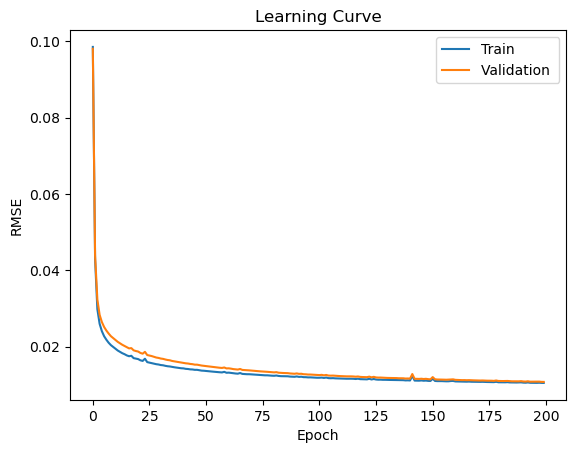

In [ ]:
# Training Results

X_trn, y_trn, X_vld, y_vld, X_tst, y_tst = get_preprocessed_data()

nn = NeuralNetwork(
    hidden_neurons=29,
    output_neurons=1,
    batch_size=61,
    alpha=0.06,
    epochs=200, #100
    seed=0,
    )

nn.fit(X_trn, y_trn, X_vld=X_vld, y_vld=y_vld)
y_hat_trn = nn.predict(X_trn)
trn_mse_score = mse(y_trn, y_hat_trn)
print(f"Train MSE: {trn_mse_score}")
trn_rmse_score = rmse(y_trn, nn.predict(X_trn))
print(f"Train RMSE: {trn_rmse_score}")            


y_hat_vld = nn.predict(X_vld)
vld_mse_score = mse(y_vld, y_hat_vld)
print(f"Validation MSE: {vld_mse_score}")
trn_rmse_score = rmse(y_vld, nn.predict(X_vld))
print(f"Train RMSE: {trn_rmse_score}")   

y_hat_tst = nn.predict(X_tst)
tst_mse_score = mse(y_tst, y_hat_tst)
print(f"Test MSE: {tst_mse_score}")
trn_rmse_score = rmse(y_tst, nn.predict(X_tst))
print(f"Test RMSE: {trn_rmse_score}")   

plt.plot(nn.trn_error, label='Train ')
plt.plot(nn.vld_error, label='Validation ')
plt.title("Learning Curve")
plt.ylabel("RMSE")
plt.xlabel("Epoch")
plt.legend()
plt.show()

#### 3.2    algortithm 1

#### 4      Results

#### 4.1    Experimental Setup      


#### 4.2    Observations


#### 4.3    Anlaysis


#### 4.4    Experiments to Support Analysis   

#### 5      Conclusions

Provide concluding remarks about the project (1-2 paragraphs)

Can discuss the following:
-Thoughts about the project
-What you have learned
-Challenges and how you overcome them

## References and Citations    Use MLA style to cite and reference others work! using MLA 8th edition
Works Cited

Prasad, Arvind and Shalini Chandra. "PhiUSIIL Phishing URL (Website)." UCI Machine Learning Repository, 2024, https://doi.org/10.1016/j.cose.2023.103545.

#### AI Assistance



## Acknowledgement

In [48]:
Link to Source Code 

SyntaxError: invalid syntax (762515468.py, line 1)